Importing Library and Loading Dataset
Converting Date Columns into datetime objects (Useful for time-series operations (e.g., grouping by month))

In [5]:
import pandas as pd
df = pd.read_csv("Sales Dataset.csv")
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year-Month'] = pd.to_datetime(df['Year-Month'])

Displaying Data Info (Summary of the DataFrame, including column types and null values)

In [6]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      1194 non-null   object        
 1   Amount        1194 non-null   int64         
 2   Profit        1194 non-null   int64         
 3   Quantity      1194 non-null   int64         
 4   Category      1194 non-null   object        
 5   Sub-Category  1194 non-null   object        
 6   PaymentMode   1194 non-null   object        
 7   Order Date    1194 non-null   datetime64[ns]
 8   CustomerName  1194 non-null   object        
 9   State         1194 non-null   object        
 10  City          1194 non-null   object        
 11  Year-Month    1194 non-null   datetime64[ns]
dtypes: datetime64[ns](2), int64(3), object(7)
memory usage: 112.1+ KB
None


Displaying the first 5 rows of data for a quick preview

In [7]:
print(df.head())

  Order ID  Amount  Profit  Quantity     Category      Sub-Category  \
0  B-26776    9726    1275         5  Electronics  Electronic Games   
1  B-26776    9726    1275         5  Electronics  Electronic Games   
2  B-26776    9726    1275         5  Electronics  Electronic Games   
3  B-26776    4975    1330        14  Electronics          Printers   
4  B-26776    4975    1330        14  Electronics          Printers   

  PaymentMode Order Date   CustomerName     State     City Year-Month  
0         UPI 2023-06-27  David Padilla   Florida    Miami 2023-06-01  
1         UPI 2024-12-27  Connor Morgan  Illinois  Chicago 2024-12-01  
2         UPI 2021-07-25   Robert Stone  New York  Buffalo 2021-07-01  
3         UPI 2023-06-27  David Padilla   Florida    Miami 2023-06-01  
4         UPI 2024-12-27  Connor Morgan  Illinois  Chicago 2024-12-01  


Cleaning the Data
(Removes any duplicate rows from the dataset)
(Filters out any rows where the 'Amount' value is negative. Only keeps rows with Amount >= 0)

In [8]:
df.drop_duplicates(inplace=True)
df = df[df['Amount'] >= 0]

Preparing Data for Forecasting
(Resets the index so it's a clean DataFrame)

In [ ]:
monthly_sales = df.groupby('Year-Month')['Amount'].sum().reset_index() #Groups the data by 'Year-Month' and sums the 'Amount' for each month.
monthly_sales.columns = ['ds', 'y']  # Rename for Prophet -> ds: date & y: value to forecast


Plotting Monthly Sales Over Time

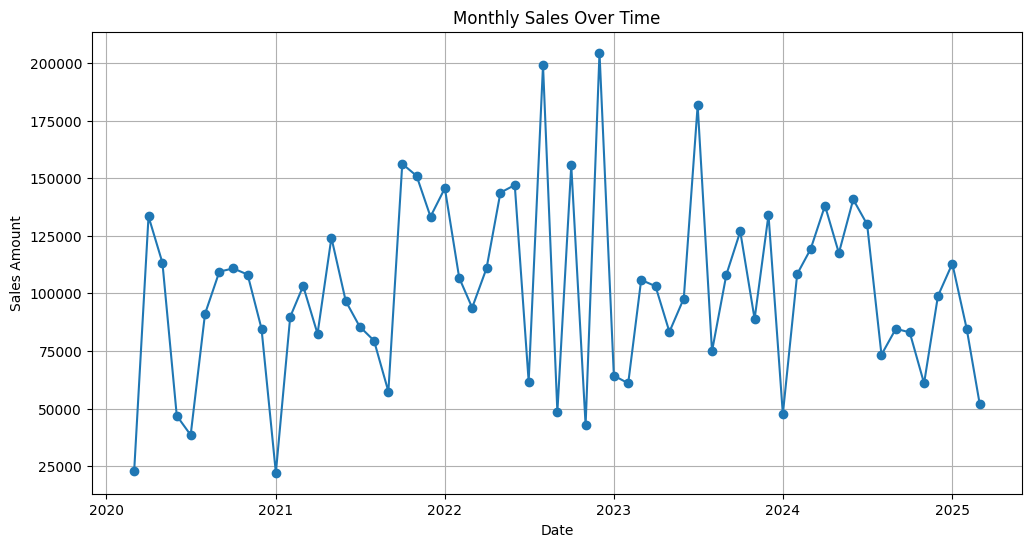

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales['ds'], monthly_sales['y'], marker='o')
plt.title("Monthly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales Amount")
plt.grid(True)
plt.show()


Plotting Sales by State

C:\Users\Aarya\AppData\Local\Temp\ipykernel_23896\3070023200.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_sales.values, y=state_sales.index, palette='Spectral')


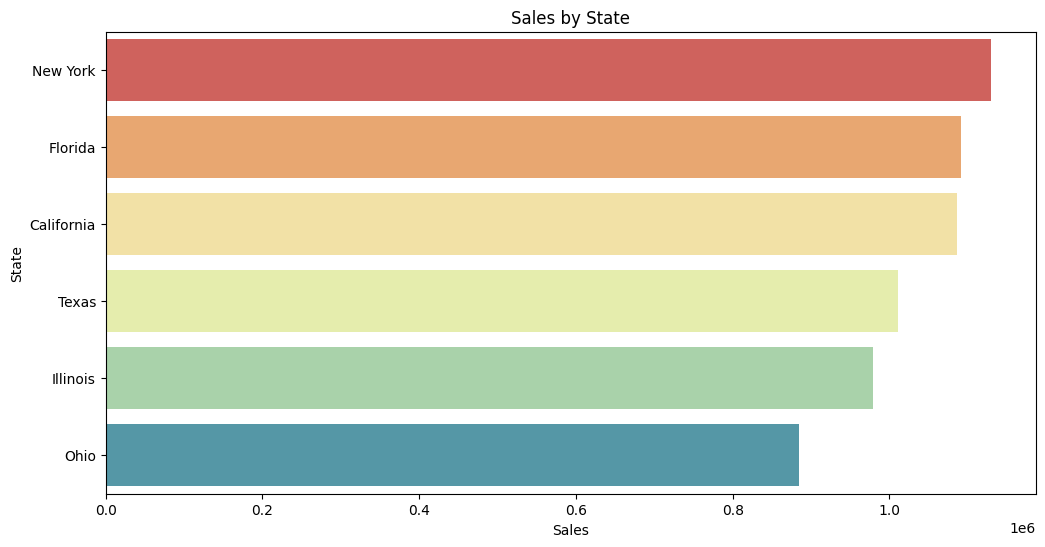

In [12]:
import seaborn as sns
state_sales = df.groupby('State')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=state_sales.values, y=state_sales.index, palette='Spectral')
plt.title("Sales by State")
plt.xlabel("Sales")
plt.show()


Sorts Top 10 Cities by Profit

C:\Users\Aarya\AppData\Local\Temp\ipykernel_23896\1168951834.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_profit.values, y=city_profit.index, palette='cubehelix')


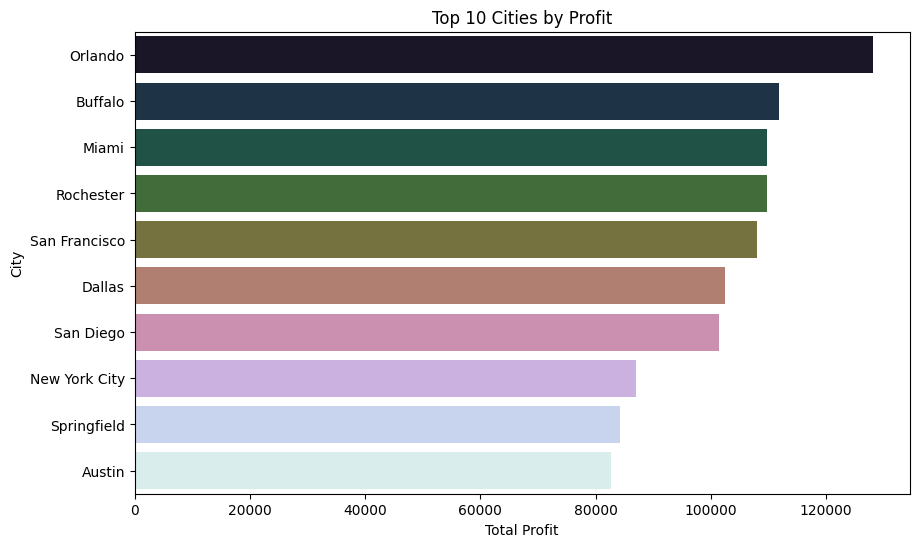

In [13]:
city_profit = df.groupby('City')['Profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=city_profit.values, y=city_profit.index, palette='cubehelix')
plt.title("Top 10 Cities by Profit")
plt.xlabel("Total Profit")
plt.show()


Plot Quantity vs Profit
(Helps identify if selling more quantity always results in more profit.) 
(Read more)

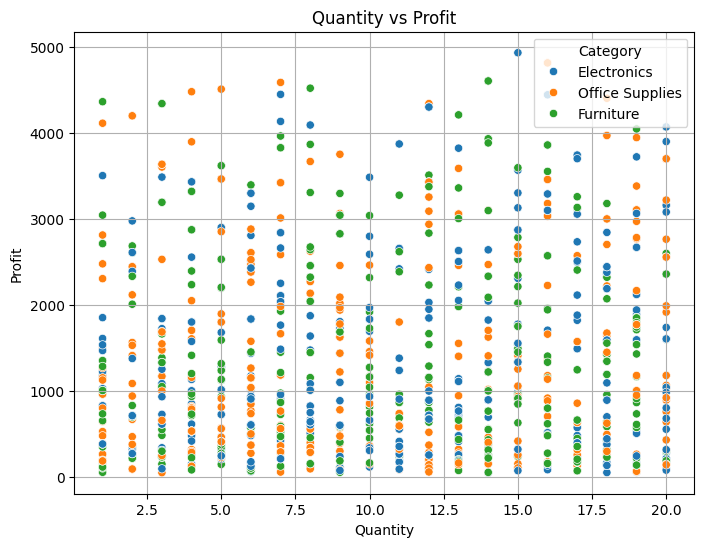

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Quantity', y='Profit', hue='Category') #Uses color (hue='Category') to distinguish different product categories.
plt.title("Quantity vs Profit")
plt.grid(True)
plt.show()


Display Top 10 Frequent Buyers

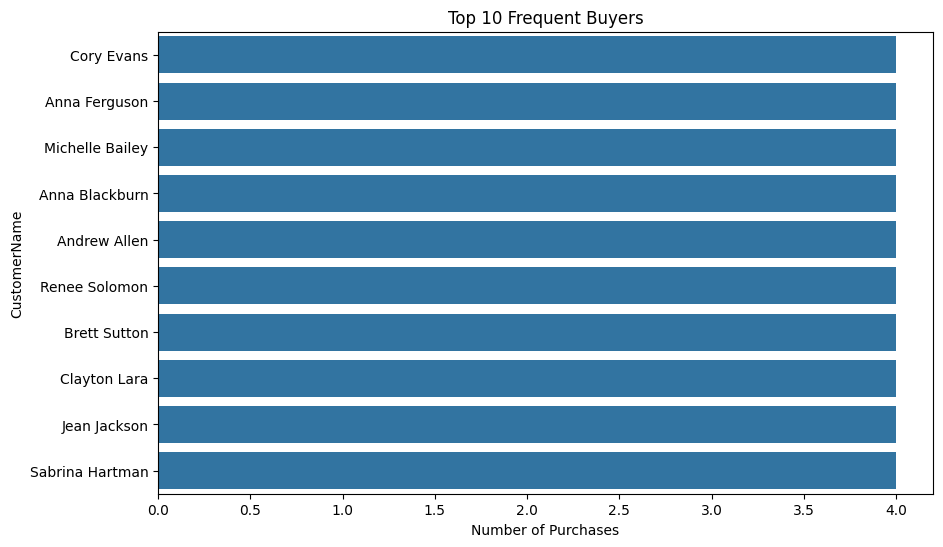

In [15]:
customer_freq = df['CustomerName'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=customer_freq.values, y=customer_freq.index)
plt.title("Top 10 Frequent Buyers")
plt.xlabel("Number of Purchases")
plt.show()


In [20]:
%pip install scikit-learn

   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.1 MB 4.8 MB/s eta 0:00:03
   ---- ----------------------------------- 1.3/11.1 MB 3.4 MB/s eta 0:00:03
   ------ --------------------------------- 1.8/11.1 MB 3.6 MB/s eta 0:00:03
   -------- ------------------------------- 2.4/11.1 MB 2.8 MB/s eta 0:00:04
   ---------- ----------------------------- 2.9/11.1 MB 2.8 MB/s eta 0:00:03
   ------------- -------------------------- 3.7/11.1 MB 2.9 MB/s eta 0:00:03
   ---------------- ----------------------- 4.5/11.1 MB 3.1 MB/s eta 0:00:03
   ---------------- ----------------------- 4.7/11.1 MB 2.9 MB/s eta 0:00:03
   ------------------- -------------------- 5.5/11.1 MB 2.9 MB/s eta 0:00:02
   ---------------------- ----------------- 6.3/11.1 MB 3.0 MB/s eta 0:00:02
   -------------------------- ------------- 7.3/11.1 MB 3.2 MB/s eta 0:00:02
   ------------------------------ --------- 8.4/11.1 MB 3.3 MB/s eta 0:00:01
   ---

Applying Clustering with K-Means (Segmentation)

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Feature selection 
X = df[['Quantity', 'Profit']]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Applying Elbow Method to find optimal clusters

Text(0.5, 1.0, 'Elbow Method for Optimal k')

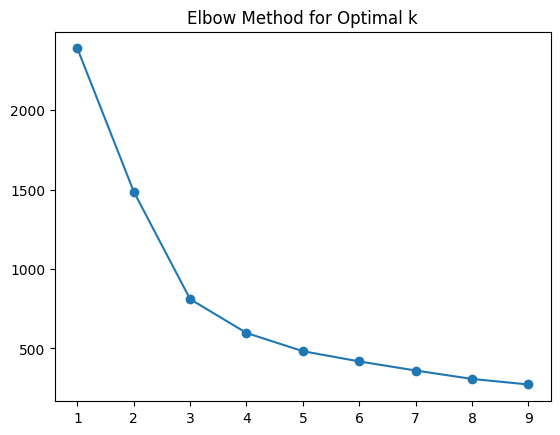

In [22]:
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.title("Elbow Method for Optimal k")


Apply K-Means with k=3 (Obtained from Elbow Method)

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled) # Creates 3 clusters and adds them as a new column Cluster

Visualizing Clusters

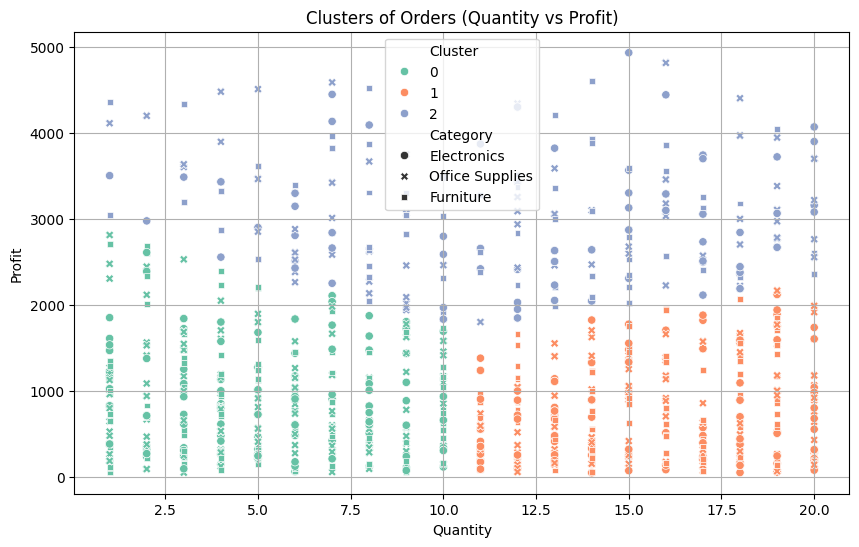

In [42]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Quantity', y='Profit', hue='Cluster', palette='Set2', style='Category')
plt.title("Clusters of Orders (Quantity vs Profit)")
plt.grid(True)
plt.show()

In [25]:
%pip install prophet

   ---------------------------------------- 0.0/13.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.3 MB ? eta -:--:--
    --------------------------------------- 0.3/13.3 MB ? eta -:--:--
    --------------------------------------- 0.3/13.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/13.3 MB 558.9 kB/s eta 0:00:23
   - -------------------------------------- 0.5/13.3 MB 558.9 kB/s eta 0:00:23
   -- ------------------------------------- 0.8/13.3 MB 578.7 kB/s eta 0:00:22
   --- ------------------------------------ 1.3/13.3 MB 907.1 kB/s eta 0:00:14
   ----- ---------------------------------- 1.8/13.3 MB 1.1 MB/s eta 0:00:11
   ------- -------------------------------- 2.4/13.3 MB 1.4 MB/s eta 0:00:09
   --------- ------------------------------ 3.1/13.3 MB 1.6 MB/s eta 0:00:07
   ----------- ---------------------------- 3.7/13.3 MB 1.7 MB/s eta 0:00:06
   ------------- -------------------------- 4.5/13.3 MB 1.9 MB/s eta 0:00:05
   -------------- -

Forecasting Future Sales using Prophet

23:54:54 - cmdstanpy - INFO - Chain [1] start processing
23:54:54 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Aarya\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


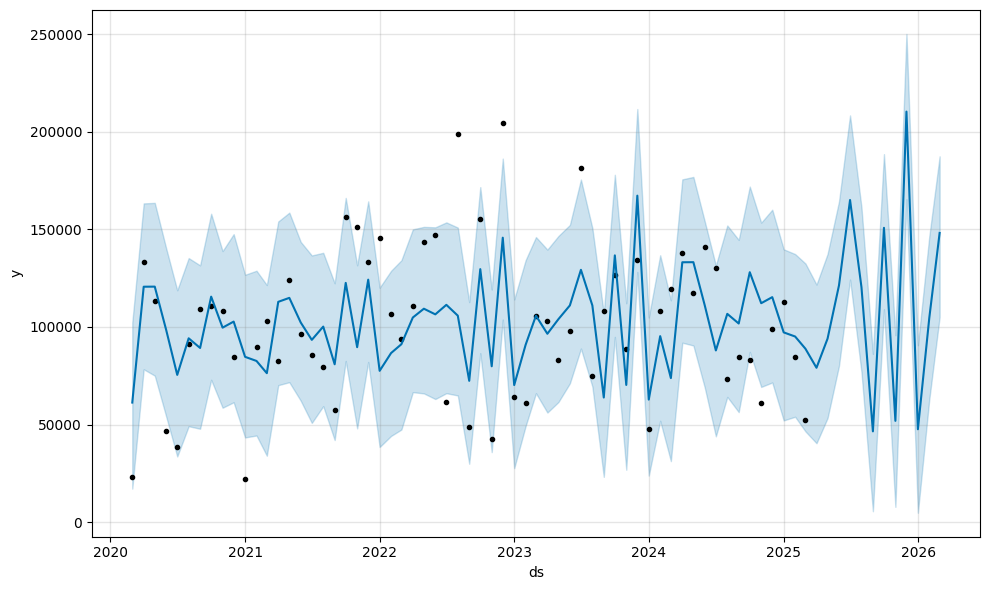

In [ ]:
from prophet import Prophet

model = Prophet()
model.fit(monthly_sales)

future = model.make_future_dataframe(periods=12, freq='M')
forecast = model.predict(future)
fig = model.plot(forecast) # Visualizes forecast with confidence intervals.

Forecast Components 

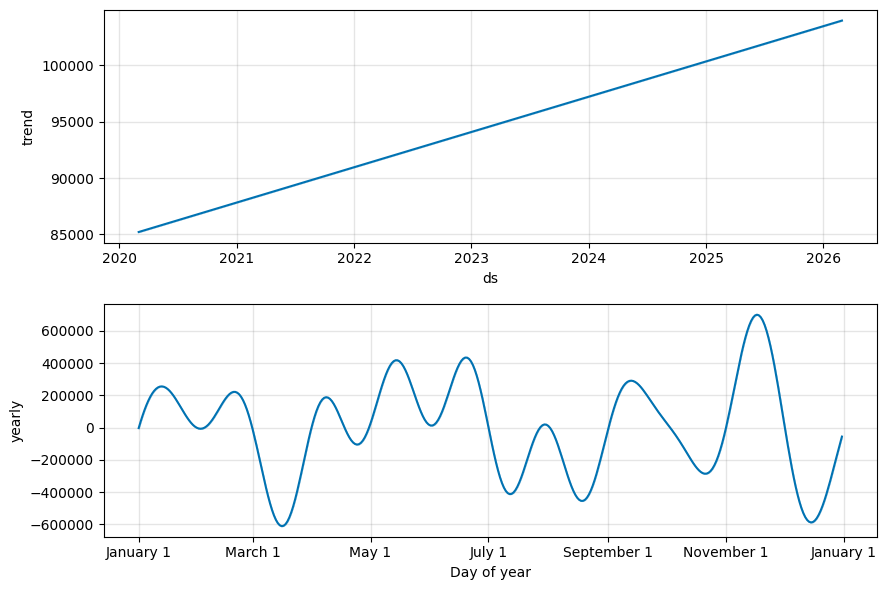

In [ ]:
fig = model.plot_components(forecast) #Shows trend, seasonality, and holidays (if any) from forecasted sales.

Forecast Evaluation (Mean Absolute Error)

In [48]:
from sklearn.metrics import mean_absolute_error

y_true = monthly_sales['y'][-6:].values
y_pred = forecast['yhat'][-6:].values
mae = mean_absolute_error(y_true, y_pred) #Compares last 6 months of actual vs predicted sales using Mean Absolute Error (MAE)
print("MAE:", mae)


MAE: 61559.735773661676


Plot Top Categories by Revenue

C:\Users\Aarya\AppData\Local\Temp\ipykernel_23896\1377002387.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette="Blues_d")


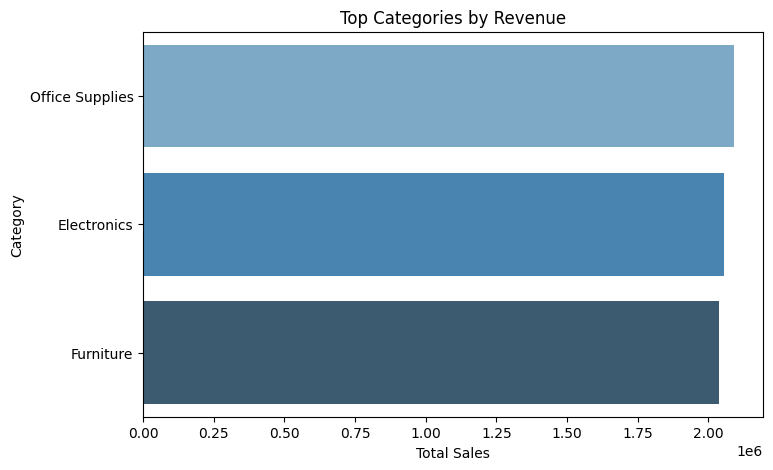

In [35]:
top_categories = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=top_categories.values, y=top_categories.index, palette="Blues_d")
plt.title("Top Categories by Revenue")
plt.xlabel("Total Sales")
plt.show()

Plot Top Sub-Categories by Revenue

C:\Users\Aarya\AppData\Local\Temp\ipykernel_23896\4054953248.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_subcategories.values, y=top_subcategories.index, palette="Greens_d")


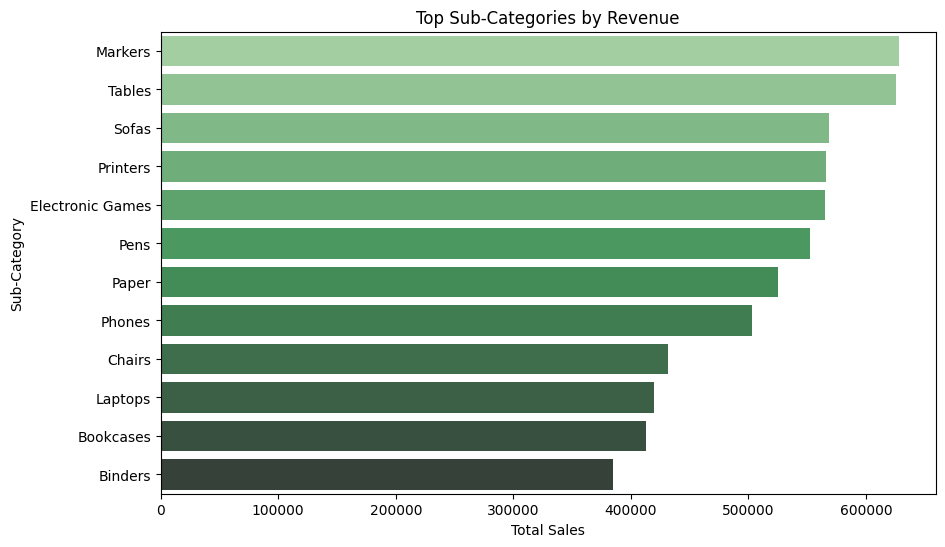

In [36]:
top_subcategories = df.groupby('Sub-Category')['Amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_subcategories.values, y=top_subcategories.index, palette="Greens_d")
plt.title("Top Sub-Categories by Revenue")
plt.xlabel("Total Sales")
plt.show()

Heatmap of Sales and Profit by State

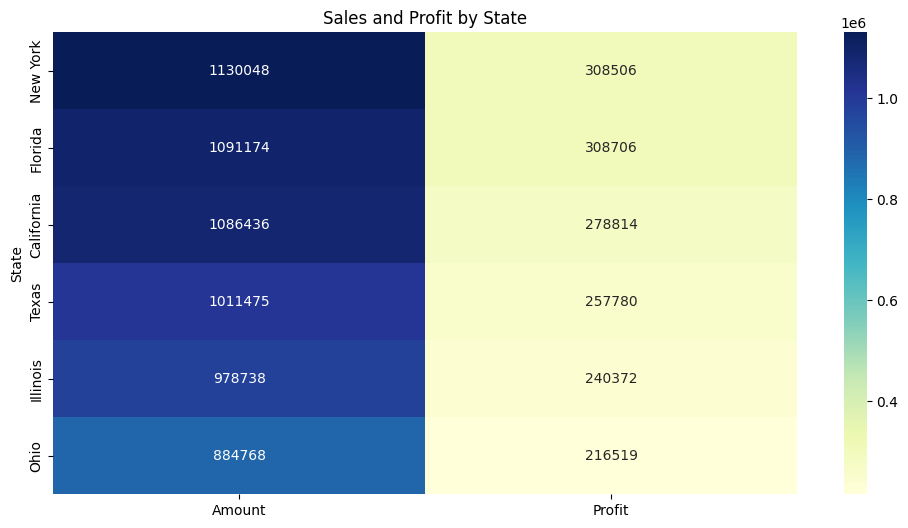

In [37]:
state_sales_profit = df.groupby('State')[['Amount', 'Profit']].sum().sort_values(by='Amount', ascending=False)
plt.figure(figsize=(12, 6))
sns.heatmap(state_sales_profit, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Sales and Profit by State")
plt.show()


Payment Method Distribution

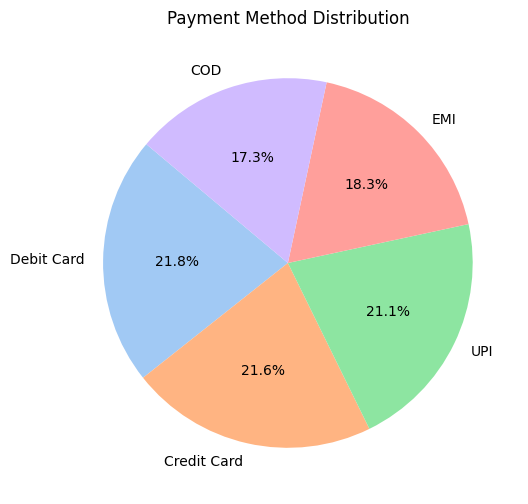

In [38]:
payment_dist = df['PaymentMode'].value_counts()
plt.figure(figsize=(6, 6))
payment_dist.plot.pie(autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()


Plot Top 10 Customers by Sales

C:\Users\Aarya\AppData\Local\Temp\ipykernel_23896\3835933681.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers.values, y=top_customers.index, palette="coolwarm")


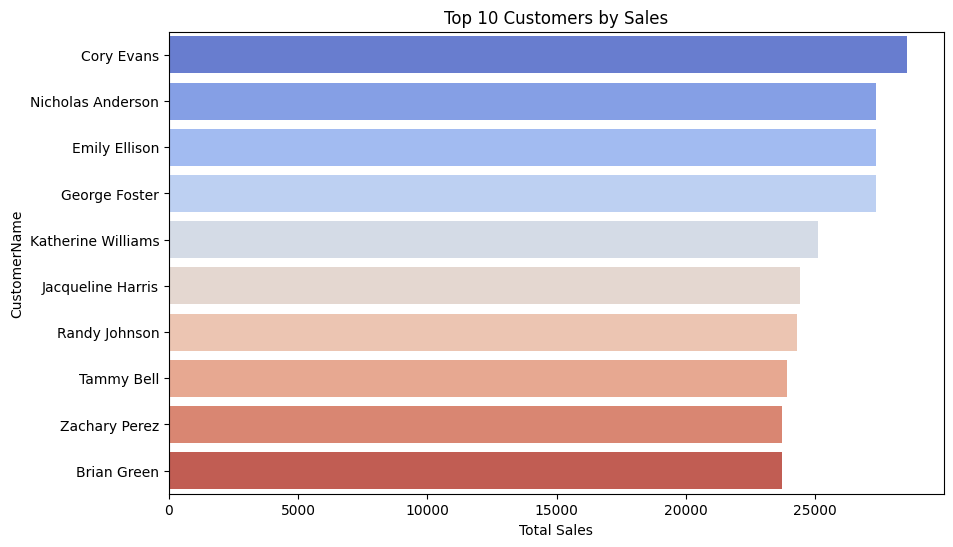

In [41]:
top_customers = df.groupby('CustomerName')['Amount'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_customers.values, y=top_customers.index, palette="coolwarm")
plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales")
plt.show()